In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score,f1_score
from tqdm.notebook import tqdm
import os
import anndata as ad
import matplotlib.pyplot as plt

In [2]:
from sklearn.ensemble import RandomForestClassifier
def random_forest_classifier(
      adata,
      y_col='geo_region_of_origin',
      n_estimators=500,
      max_features='sqrt',
      label='90/10',
      random_state=0,
  ):
    # encode classes
    #uses pre-computed folds to calculate the data with adata.obsm[fold]
    # Here the
    classes = sorted(adata.obs[y_col].unique().tolist())
    class_dict = {c: i for i, c in enumerate(classes)}
    adata.obs['class_id'] = adata.obs[y_col].map(class_dict)


    # remove classes with too few samples
    fold_ids = sorted(list(adata.obsm.keys()))

    class_counts = adata.obs['class_id'].value_counts()
    keep_classes = class_counts[class_counts >= len(fold_ids)].index
    adata = adata[adata.obs['class_id'].isin(keep_classes)].copy()
    
    fold_ids = sorted(list(adata.obsm.keys()))
    adata.obs['fold_' + label] = None
    for i, fold in enumerate(fold_ids):
        fold_col = adata.obsm[fold][:, -1]
        test_mask = fold_col == 1
        train_mask = ~test_mask
        X_train = adata.obsm[fold][train_mask, :-1]
        X_test  = adata.obsm[fold][test_mask,  :-1]
        y_train = adata.obs.loc[train_mask, 'class_id'].to_numpy()

        clf = RandomForestClassifier(
              n_estimators=n_estimators,
              max_features=max_features,
              random_state=random_state,
              n_jobs=-1,
          )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        adata.obs.loc[test_mask, 'pred'] = preds
        adata.obs.loc[test_mask, 'fold_' + label] = i

    return adata

In [3]:
n_tree_vals = [100]
split_files = sorted([f for f in os.listdir('../data/') if f.startswith('pcScores')])
f1s = np.zeros((len(split_files), len(n_tree_vals), 10))

for s, split_file in enumerate(split_files):
    adata = ad.read_h5ad(os.path.join('../data', split_file))
    split_no = split_file.split('.')[0][-2:]
    # Each PCA split has different folds
    for j, n_trees in tqdm(list(enumerate(n_tree_vals)), desc=split_file):
        result = random_forest_classifier(adata.copy(), n_estimators=n_trees, label=split_no)
        print(result)
        fold_col = 'fold_' + split_no
        folds = result.obs[fold_col].dropna().unique()
        for f, fold in enumerate(folds):
            sub = result[result.obs[fold_col] == fold].obs
            print(s, j, f)
            f1s[s, j, f] = f1_score(sub['class_id'].to_numpy(),
                                      sub['pred'].to_numpy(),
                                      average='macro')

pcScores_split_10.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_10', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_10', 'X_pca_fold_2', 'X_pca_fold_3', 'X_pca_fold_4', 'X_pca_fold_5', 'X_pca_fold_6', 'X_pca_fold_7', 'X_pca_fold_8', 'X_pca_fold_9'
0 0 0
0 0 1
0 0 2
0 0 3
0 0 4
0 0 5
0 0 6
0 0 7
0 0 8
0 0 9


pcScores_split_20.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_20', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_2', 'X_pca_fold_3', 'X_pca_fold_4', 'X_pca_fold_5'
1 0 0
1 0 1
1 0 2
1 0 3
1 0 4


pcScores_split_25.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_25', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_2', 'X_pca_fold_3', 'X_pca_fold_4'
2 0 0
2 0 1
2 0 2
2 0 3


pcScores_split_33.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_33', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_2', 'X_pca_fold_3'
3 0 0
3 0 1
3 0 2


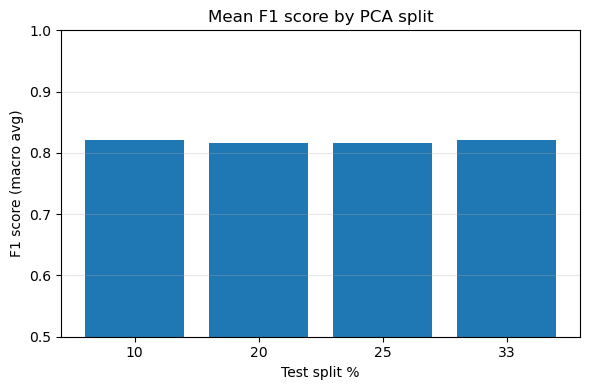

In [4]:
splits = ['10', '20', '25', '33']
n_folds_per_split = [10, 5, 4, 3]

mean_scores = []
for s, n_folds in enumerate(n_folds_per_split):
    fold_scores = [f1s[s, 0, f] for f in range(n_folds)]
    mean_scores.append(np.mean(fold_scores))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(splits, mean_scores)
ax.set_xlabel('Test split %')
ax.set_ylabel('F1 score (macro avg)')
ax.set_title('Mean F1 score by PCA split')
ax.set_ylim(.5, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [5]:
from itertools import product

param_grid = {
    "max_depth":         [5, 10, 20, None],
    "max_features":      ["sqrt", "log2", 0.1, 0.25, 0.5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 5, 10],
    "bootstrap":         [True]
}

adata = ad.read_h5ad('../data/pcScores_split_20.h5ad')

all_results = []

#generate all combinations of the hyperparameters

keys = list(param_grid.keys())
vals = list(param_grid.values())


# loop over all parameter combinations and finds all of the cartersian products of all values and computes each fold with the specific parameter combination

#finding cartersian product to gather every possibly combo of hypyerparameters

for combin in product(*vals):
    params = dict(zip(keys,combin))
    # print(f" Testing: {params}")

    result = random_forest_classifier(
        adata.copy(),
        n_estimators = 100,
        max_features = params['max_features'],
        label = '20',
        random_state = 0
    )

    # find f1 score per given fold
    # compute F1 per fold
    # uses predefined folds from data structure
    fold_col = 'fold_20'
    folds = result.obs[fold_col].dropna().unique()
    fold_f1s = []
    for fold in folds:
        sub = result[result.obs[fold_col] == fold].obs
        f1 = f1_score(
            sub['class_id'].to_numpy(),
            sub['pred'].to_numpy(),
            average='macro'
        )
        # adds all f1 scores to the list
        fold_f1s.append(f1)
    # average the f1 scores from each fold
    avg_f1 = np.mean(fold_f1s)

    #saves the particular combination of hyperparameters and f1 score to all results
    all_results.append({
        'max_features':      params['max_features'],
        'max_depth':         params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf':  params['min_samples_leaf'],
        'avg_f1':            avg_f1
    })

    # save after every combination
    pd.DataFrame(all_results).to_csv('../data/gridsearch_results.csv', index=False)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('avg_f1', ascending=False)

print("\n=== Top 10 combinations ===")
print(results_df.head(10).to_string(index=False))

print("\n=== Best overall combination ===")
print(results_df.iloc[0])


=== Top 10 combinations ===
max_features  max_depth  min_samples_split  min_samples_leaf   avg_f1
         0.5        NaN                 10                10 0.850593
         0.5        5.0                  2                 1 0.850593
         0.5       20.0                  5                 2 0.850593
         0.5       20.0                  5                 1 0.850593
         0.5       20.0                  2                10 0.850593
         0.5       20.0                  2                 5 0.850593
         0.5       20.0                  2                 2 0.850593
         0.5       20.0                  2                 1 0.850593
         0.5        5.0                 10                10 0.850593
         0.5        5.0                 10                 5 0.850593

=== Best overall combination ===
max_features              0.5
max_depth                 NaN
min_samples_split          10
min_samples_leaf           10
avg_f1               0.850593
Name: 239, dtype: